In [144]:
"""Tutorial: Complete Bayesian Optimal Experimental Design workflow.

This is the main entry point demonstrating the full pyCBOED workflow:
1. Setting up a forward PDE model
2. Defining a Gaussian Process prior
3. Generating synthetic observations
4. Performing Bayesian inference
5. Evaluating design criteria
6. Visualizing results

This example uses a 1D advection-diffusion PDE with a Gaussian Process prior
on the initial condition. It demonstrates linear Gaussian inference and
multiple design optimality criteria.
"""
import numpy as np
from boed.core.base import validate_positive_definite
from boed.core import make_u0
from boed.priors.kernels import Gaussian, Matern12, Matern32
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel
from boed.pde.advection_diffusion import AdvectionDiffusion1D_CN
from boed.pde.burgers import BurgersNonLinear_CN
from boed.viz.boed_visualizer_pro import BOEDVisualizerPro
from boed.inference import LinearGaussianModel, ObservationMap
from boed.observations.sensors import SpaceTimeSensors
from boed.core.utils import compute_W,generate_synthetic_observations

SEED = 42
np.random.seed(SEED)


In [158]:
# ===============================================================================
# PARAMETERS
# ===============================================================================
N = 200
dt = 0.0025
n_steps = 250
diffusivity = 0.01
velocity = 0.5


In [159]:

# ------------------- PDE -------------------
# model = AdvectionDiffusion1D_CN(N, dt, diffusivity=diffusivity, velocity=velocity)
model = BurgersNonLinear_CN(N, dt=dt, diffusivity=diffusivity)
x_grid = np.linspace(0,1,N)
# stable, msg = model.check_stability()
# print(msg)


In [160]:

# ------------------- Prior -------------------
kernel = Gaussian(length_scale=1, sigma=1.0)
prior_process = GaussianProcessPrior(kernel, nx=N)
Sigma_prior = prior_process.Sigma
mu_prior = prior_process.mu
x_prior = prior_process.x
validate_positive_definite(Sigma_prior, "Prior covariance")


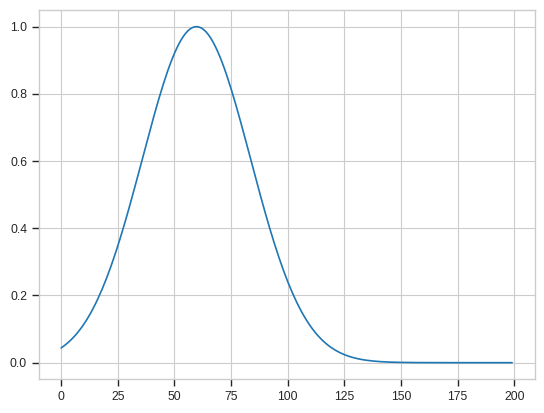

In [161]:

# ------------------- Synthetic data -------------------
u_true = make_u0(
    x_grid,
    "gaussian",
)
trajectory = model.evolve(u_true, n_steps)
plt.plot(u_true)


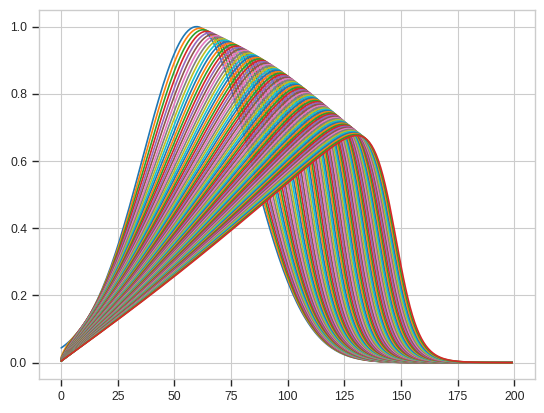

In [162]:
import matplotlib.pyplot as plt
U = model.evolve(u0=u_true,n_steps=n_steps)
n, _ = U.shape
for i in range(n) : 
    if i%3 == 0 :
        plt.plot(U[i,:])
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


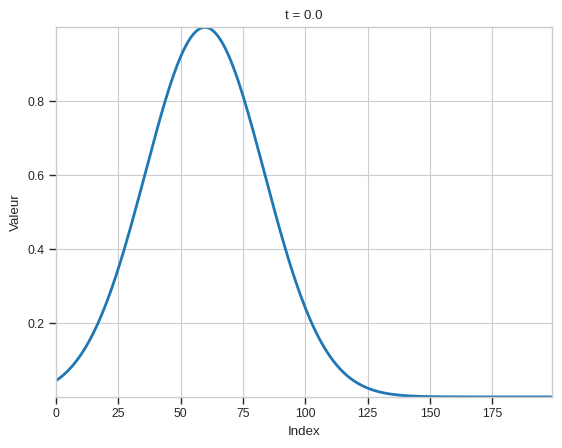

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

U = model.evolve(u0=u_true, n_steps=n_steps)
n, m = U.shape

frames = np.arange(0, n, 1)

fig, ax = plt.subplots()
x = np.arange(m)
line, = ax.plot(x, U[0, :], lw=2)

ax.set_xlim(0, m-1)
ax.set_ylim(U.min(), U.max())
ax.set_xlabel("Index")
ax.set_ylabel("Valeur")

def update(k):
    i = frames[k]
    line.set_ydata(U[i, :])
    ax.set_title(f"t = {i*dt}")
    return (line,)

ani = FuncAnimation(
    fig, update,
    frames=len(frames),
    interval=50,   # ms (augmente si trop rapide)
    blit=False     # <- important : évite les soucis d'affichage
)

ani.save("anim_burgers.png")


In [164]:

noise = NoiseModel(sigma_noise=0.00001)
y_obs = trajectory + noise.sample(N, n_samples=n_steps+1)  # shape matches trajectory

A = model.get_forward_operator(n_steps=n_steps, u0_ref=u_true)
y_final = y_obs[(n_steps-1)//2, :]
Sigma_noise = noise.get_covariance(N)


In [165]:
# --- Reconstruction de u0 (Condition Initiale) ---
lgm = LinearGaussianModel(A=A, Sigma_noise=Sigma_noise, mu_prior=mu_prior, Sigma_prior=Sigma_prior)
mu_post, Sigma_post = lgm.posterior(y_final)

# --- Visualisation de la réussite ---
viz = BOEDVisualizerPro(output_dir="results")

# On compare mu_post à u_true (tous deux sont à t=0)
viz.plot_field(
    x_grid, u_true, mu_post, Sigma_post,
    title="Reconstruction de la Condition Initiale (u0)",
    filename="reconstruction_u0.png"
)


In [166]:

# --- Bonus : Vérification de la prédiction à t=T ---
# Si on propage notre estimation, elle doit coller aux observations
mu_final_pred = A @ mu_post
Sigma_final_pred = A @ Sigma_post @ A.T

viz.plot_field(
    x_grid, trajectory[n_steps-1, :], mu_final_pred, Sigma_final_pred,
    title="Prédiction du champ final observé (uT)",
    filename="prediction_uT.png"
)


In [167]:
np.random.seed(42)
sensors = np.random.randint(low=0,high=N,size=10)
# sensors = np.linspace(0, N//2 ,100, dtype=int)
obs_map = ObservationMap.from_indices(sensors, n_obs=N)

mu_sens, Sigma_sens = lgm.posterior(y=y_final, obs_map=obs_map)

# --- Visualisation de la réussite ---
viz = BOEDVisualizerPro(output_dir="results")

# On compare mu_post à u_true (tous deux sont à t=0)
viz.plot_field(
    x_grid, u_true, mu_sens, Sigma_sens,
    title="Reconstruction de la Condition Initiale sensors",
    filename="reconstruction_u0_sensors.png",
    sensor_indices=sensors
)


In [168]:
from typing import Optional, Tuple

from matplotlib import pyplot as plt


def plot_qoi(
    x_grid: np.ndarray,
    mu_z: np.ndarray,
    Sigma_z: np.ndarray,
    z_true: Optional[np.ndarray] = None,
    title: str = "Analyse de la Quantité d'Intérêt",
    filename: str = "qoi_analysis.png",
    figsize: Tuple[int, int] = (12, 6)
):
    """
    Trace la QoI : soit sous forme de cloche de Gauss (si scalaire), 
    soit sous forme de champ local (si matrice).
    """
    import scipy.stats as stats
    
    # On aplatit les entrées pour être sûr des dimensions
    mu_z_flat = np.ravel(mu_z)
    
    # --- CAS 1 : QoI SCALAIRE (G est un vecteur ligne) ---
    if mu_z_flat.size == 1:
        fig, ax = plt.subplots(figsize=figsize)
        mu_val = mu_z_flat[0]
        std_val = np.sqrt(np.ravel(Sigma_z)[0])
        
        # Axe des abscisses pour la cloche (4 sigmas autour de la moyenne)
        z_axis = np.linspace(mu_val - 4*std_val, mu_val + 4*std_val, 200)
        pdf = stats.norm.pdf(z_axis, mu_val, std_val)
        
        # Tracé de la cloche
        ax.plot(z_axis, pdf, lw=2, color='C1', label="Distribution (Posterior)")
        ax.fill_between(z_axis, pdf, alpha=0.25, color='C1')
        
        # Vérité terrain (ligne verticale)
        if z_true is not None:
            ax.axvline(np.ravel(z_true)[0], color='C0', lw=2.5, label="Vraie Valeur")
            
        ax.set_title(f"{title} (Scalaire)")
        ax.set_xlabel("Valeur de la QoI")
        ax.set_ylabel("Densité de probabilité")

    # --- CAS 2 : QoI MATRICIELLE (G est une matrice) ---
    else:
        fig, ax = plt.subplots(figsize=figsize)
        M = mu_z_flat.size
        x_qoi = x_grid[:M]  # On suppose que G sélectionne les M premiers points
        std_z = np.sqrt(np.diag(Sigma_z))
        
        # Tracé du champ extrait avec son tube d'incertitude
        ax.plot(x_qoi, mu_z_flat, lw=2, ls="--", color='C1', label="Moyenne QoI")
        ax.fill_between(
            x_qoi,
            mu_z_flat - 1.96 * std_z,
            mu_z_flat + 1.96 * std_z,
            color='C1',
            alpha=0.25,
            label="95% CI (QoI)"
        )
        
        # Vérité terrain (courbe)
        if z_true is not None:
            ax.plot(x_qoi, np.ravel(z_true), lw=2.5, color='C0', label="Vraie QoI")
            
        ax.set_title(f"{title} (Spatiale)")
        ax.set_xlabel("x")
        ax.set_ylabel("Valeur")

    ax.grid(alpha=0.3)
    ax.legend(fontsize=10, frameon=True)
    
    plt.show()

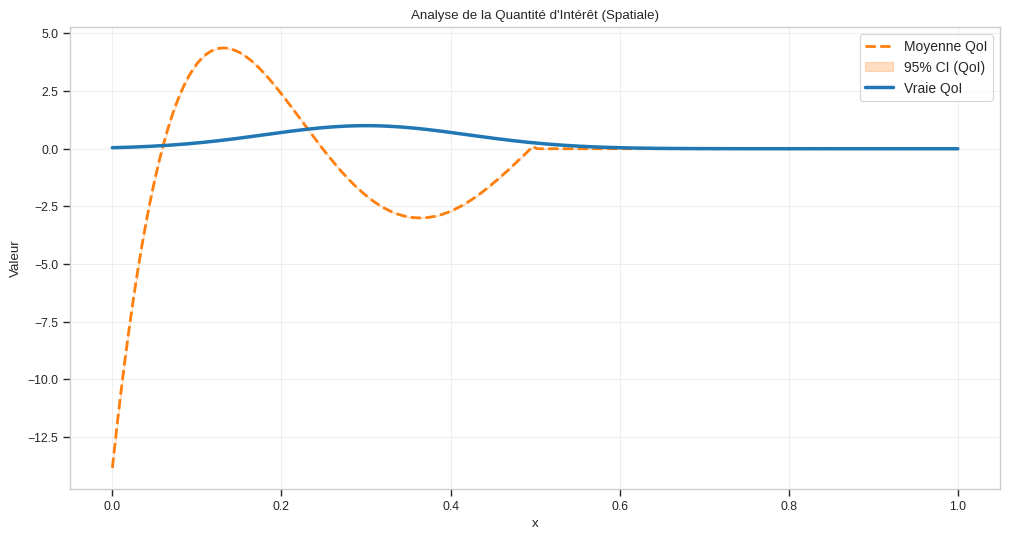

In [169]:
# Hypothèse : N est la taille de theta
N_theta = len(mu_prior)
half_N = N_theta // 2
indices = np.arange(0,half_N,1)

# 1. Construction de G (Matrice de sélection)
G = compute_W(N=N_theta, indices=indices)

# 2. Calcul des statistiques de la QoI (z = G @ theta)
mu_z = G @ mu_post
Sigma_z = G @ Sigma_post @ G.T

plot_qoi(
    x_grid,
    mu_z,
    Sigma_z,
    u_true
)

In [157]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Calcul des deux incertitudes ---
# Incertitude globale (diagonale de Sigma_post)
std_global = np.sqrt(np.diag(Sigma_post))

# Incertitude QoI (on utilise G pour isoler la zone)
# z = G @ mu_post, Sigma_z = G @ Sigma_post @ G.T
mu_z, Sigma_z = lgm.qoi_statistics(G_mat, mu_post, Sigma_post)
std_z = np.sqrt(np.diag(Sigma_z))

# --- 2. Le Graphique de Comparaison Directe ---
plt.figure(figsize=(12, 7))

# A. Le vrai champ (référence)
plt.plot(x_grid, u_true, label="Vrai Champ (u_true)", color='blue', alpha=0.6, linewidth=2)

# B. La moyenne postérieure (notre estimation)
plt.plot(x_grid, mu_post, '--', label="Moyenne Post. (mu_post)", color='black', alpha=0.8)

# C. L'incertitude GLOBALE (en gris clair)
# Elle couvre tout le domaine [0, 1]
plt.fill_between(x_grid, 
                 mu_post - 1.96 * std_global, 
                 mu_post + 1.96 * std_global, 
                 color='gray', alpha=0.15, label="Incertitude Globale (95%)")

# D. L'incertitude QoI (en rouge vif)
# Elle ne couvre que la zone définie par G [0, 0.5]
plt.fill_between(x_grid[:half_N], 
                 mu_z - 1.96 * std_z, 
                 mu_z + 1.96 * std_z, 
                 color='red', alpha=0.4, label="Incertitude ciblée (QoI)")

plt.title("Comparaison : Incertitude Globale vs Incertitude de la QoI")
plt.xlabel("Position x")
plt.ylabel("Valeur de u")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'G_mat' is not defined

In [ ]:

## ----------- Spatio temporal sensors placement ---------------------------------------

# On place des capteurs en diagonale pour suivre le transport
x_indices = np.linspace(20, 130, 10, dtype=int)
t_indices = np.linspace(0, n_steps, 10, dtype=int)

sensors = SpaceTimeSensors(x_indices, t_indices, N)
H_obs = sensors.observation_operator(n_steps + 1)
print(np.sum(H_obs))
# Extraction des données observées (y = H_obs @ u_flat)
y_obs = H_obs @ trajectory.flatten()

# Appel de votre fonction
viz.plot_spacetime_observations(trajectory, sensors, x_grid, n_steps)
